# Movilidad activa en una EIS

In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pickle
import os
import pandas as pd
from tqdm import tqdm  # Importa la función tqdm para mostrar barra de progreso en funciones o loops
import math
import pickle
import networkx as nx
import plotly.express as px
import plotly.io as pio



pd.set_option('display.max_columns', None)

# Ruta de acceso de las carpetas con la encuesta de movilidad 
path_general = "C:/Repositorio HEAT/"
mobilitySurvey23_path = path_general + "05_Base datos procesada EODH/05_Base datos procesada EODH/CSV/"
print(mobilitySurvey23_path)

C:/Repositorio HEAT/05_Base datos procesada EODH/05_Base datos procesada EODH/CSV/


# 1. Traer datos de la encuesta de movilidad

## Modulo Personas

In [2]:
'cod_per', 'cod_hg', 
'nom_mun_hg', 'cod_upl_hg', 'cod_utam_hg','zat_hg', 'estra_hg', 
'orden', 'edad', 'sexo', 'genero', 'orien_sexual','identidad_etnica', 'madre_cab_familia', 'max_nivel_edu',
'ocupacion_principal', 'actividad_economica',

'permanencia_entre_semana', 'quien_lleva/recoge_establecimiento',
'cuidado_despues_regresar', 'condicion_discapacidad', 'RLCPD','cuidado_entre_semana_discap', 'dific_princ_medios_transp_discap',
'licencia_cond_vigente', 'posee_celular', 'realiza_desplazamientos',

'modo_principal_pre-pandemia', 'modo_principal_pandemia','razón_cambio_pandemia', 'cambio_frecuencia_post-pandemia',

'cambio_modo_pico_placa', 'cambio_modo_grandes_obra','cambio_modo_seguridad', 
'acto_violencia_sexual','lugar_violencia_sexual', 'a_quien_acudio', 
'key_hg', 'key_persona', 'fexp_per>5años'

('key_hg', 'key_persona', 'fexp_per>5años')

In [ ]:
modulo_personas_df = pd.read_csv(mobilitySurvey23_path+"c. Modulo personas.csv", encoding="latin-1", sep=";")

print("Filas df completo:",len(modulo_personas_df))
# seleccionar rangos etarios a trabajar
# HEAT: 20-64 ciclismo y 20-74 caminata 

modulo_personas_df = modulo_personas_df[(modulo_personas_df["edad"]>= 20) & (modulo_personas_df["edad"]<= 64)]
print("Filas entre 20 y 64 años de edad:",len(modulo_personas_df))
print(modulo_personas_df.columns)

modulo_personas_df['fexp_per>5años'] = modulo_personas_df['fexp_per>5años'].str.replace('.', '').str.replace(',', '.').astype(float)
#modulo_personas_df[' duracion_min '] = modulo_personas_df[' duracion_min '].astype(str).str.replace(',', '.').astype(float)


modulo_personas_df.head(5)

 #Guardar el dataframe filtrado en un CSV
#modulo_personas_df.to_csv("modulo_personas_filtrado_20-74.csv", index=False, encoding="utf-8-sig")

print("Archivo CSV guardado como: modulo_personas_filtrado_20-74.csv")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_860\3682936195.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  modulo_personas_df = pd.read_csv(mobilitySurvey23_path+"c. Modulo personas.csv", encoding="latin-1", sep=";")


Filas df completo: 67556
Filas entre 20 y 64 años de edad: 44099
Index(['cod_per', 'cod_hg', 'nom_mun_hg', 'cod_upl_hg', 'cod_utam_hg',
       'zat_hg', 'estra_hg', 'orden', 'edad', 'sexo', 'genero', 'orien_sexual',
       'identidad_etnica', 'madre_cab_familia', 'max_nivel_edu',
       'ocupacion_principal', 'actividad_economica',
       'permanencia_entre_semana', 'quien_lleva/recoge_establecimiento',
       'cuidado_despues_regresar', 'condicion_discapacidad', 'RLCPD',
       'cuidado_entre_semana_discap', 'dific_princ_medios_transp_discap',
       'licencia_cond_vigente', 'posee_celular', 'realiza_desplazamientos',
       'modo_principal_pre-pandemia', 'modo_principal_pandemia',
       'razón_cambio_pandemia', 'cambio_frecuencia_post-pandemia',
       'cambio_modo_pico_placa', 'cambio_modo_grandes_obra',
       'cambio_modo_seguridad', 'acto_violencia_sexual',
       'lugar_violencia_sexual', 'a_quien_acudio', 'key_hg', 'key_persona',
       'fexp_per>5años'],
      dtype='object')

In [26]:
fig = px.histogram(modulo_personas_df, x='edad', nbins=50,
                   title='Histograma de Edad por filas (no factor de expansión)',
                   labels={'edad': 'Edad'})
# Mostrar el gráfico
fig.show()


In [4]:
modulo_personas_df["key_persona"].iloc[0]

'uuid:2ad8b488-c706-4c60-9fa3-72c9ea976bd6/accepted/B/person_b[1]'

## Modulo Viajes

### Modulo Viajes

In [5]:
# ------------------------------------------------------------------------------
# AJUSTE METODOLÓGICO: AGREGACIÓN A NIVEL PERSONA
#
# Este bloque corrige un problema de doble conteo implícito cuando se trabaja
# a nivel de viajes. Cada fila del módulo corresponde a un viaje, no a una
# persona. Si se promedian directamente las observaciones, se estaría
# ponderando por número de viajes y no por individuo, sesgando el estimador.
#
# Por esta razón:
# 1) Se construye primero el tiempo de caminata por viaje.
# 2) Luego se agregan (sum) todos los viajes por individuo (cod_pers),
#    obteniendo el tiempo total diario de caminata por persona.
# 3) A partir de esta base agregada se deben calcular los promedios
#    (simples o ponderados con fexp_vj).
#
# Con esto se garantiza que la unidad de análisis sea el individuo y no el viaje.
# ------------------------------------------------------------------------------
modulo_viajes_df = pd.read_csv(mobilitySurvey23_path+"d. Modulo viajes.csv", encoding="latin-1", sep=";")

print("Filas df completo:",len(modulo_viajes_df))
# Limpiar espacios en blanco en motivo_viaje
modulo_viajes_df["motivo_viaje"] = modulo_viajes_df["motivo_viaje"].str.strip()

# Filtrar motivos válidos
modulo_viajes_df = modulo_viajes_df[modulo_viajes_df["motivo_viaje"].isin(['A trabajar','A Estudiar'])]
print(modulo_viajes_df)
# Filtrar frecuencia
modulo_viajes_df = modulo_viajes_df[modulo_viajes_df["frecuencia_viaje"] == 'Prácticamente todos los días']

# Filtrar solo personas entre 20 y 64 (ya filtradas antes)
modulo_viajes_df = modulo_viajes_df[modulo_viajes_df['key_pers'].isin(modulo_personas_df['key_persona'])]

print("Filas filtradas por edad:", len(modulo_viajes_df))
print(modulo_viajes_df.columns)

print(modulo_viajes_df.columns)

modulo_viajes_df['fexp_vj'] = modulo_viajes_df['fexp_vj'].str.replace('.', '').str.replace(',', '.').astype(float)
modulo_viajes_df[' duracion_min '] = modulo_viajes_df[' duracion_min '].astype(str).str.replace(',', '.').astype(float)
modulo_viajes_df['t_acceso_min'] = modulo_viajes_df['t_acceso_min'].astype(str).str.replace('-', '0')
modulo_viajes_df['t_acceso_min'] = modulo_viajes_df['t_acceso_min'].astype(str).str.replace(',', '.').astype(float)
modulo_viajes_df['t_egreso_min'] = modulo_viajes_df['t_egreso_min'].astype(str).str.replace('-', '0')
modulo_viajes_df['t_egreso_min'] = modulo_viajes_df['t_egreso_min'].astype(str).str.replace(',', '.').astype(float)


# Tiempo de caminata por viaje:
# - Si el modo principal es "A PIE <15 MIN" o "A PIE > 15 MIN" -> usar duracion_min
# - Si no -> usar t_acceso_min (caminata de acceso al modo)

# identificar viajes cuyo modo principal es A PIE
modo_norm = (
    modulo_viajes_df["modo_principal_agrupado"]
      .astype(str)
      .str.strip()
      .str.upper()
)

es_a_pie = modo_norm.str.startswith("A PIE")

# caminata como modo principal
modulo_viajes_df["caminata_modo_principal_viaje"] = np.where(
    es_a_pie,
    modulo_viajes_df[" duracion_min "],
    0
)

# caminata de acceso + egreso al modo principal
modulo_viajes_df["caminata_acceso_egreso_viaje"] = np.where(
    es_a_pie,
    0,
    modulo_viajes_df["t_acceso_min"] + modulo_viajes_df["t_egreso_min"]
)

# caminata total por viaje
modulo_viajes_df["tiempo_caminata_viaje"] = (
    modulo_viajes_df["caminata_modo_principal_viaje"] +
    modulo_viajes_df["caminata_acceso_egreso_viaje"]
)
viajes_persona_df = (
    modulo_viajes_df
      .groupby("cod_pers", as_index=False)
      .agg(
          caminata_modo_principal_dia=("caminata_modo_principal_viaje", "sum"),
          caminata_acceso_egreso_dia=("caminata_acceso_egreso_viaje", "sum"),
          caminata_total_dia=("tiempo_caminata_viaje", "sum"),
          n_viajes=("cod_vj", "count")
      )
)

modulo_viajes_df = modulo_viajes_df.merge(viajes_persona_df, on="cod_pers", how="left")
modulo_viajes_df.head(3)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_860\3092873262.py:18: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  modulo_viajes_df = pd.read_csv(mobilitySurvey23_path+"d. Modulo viajes.csv", encoding="latin-1", sep=";")


Filas df completo: 100174
        cod_hg nom_mun_hg  cod_upl_hg cod_utam_hg  zat_hg   estra_hg  \
0            1     Bogotá          31     UTAM043     374          3   
2            1     Bogotá          31     UTAM043     374          3   
6            1     Bogotá          31     UTAM043     374          3   
8            1     Bogotá          31     UTAM043     374          3   
10           2     Sibaté         740     UTAM580     915  No aplica   
...        ...        ...         ...         ...     ...        ...   
100154    4295     Bogotá          26     UTAM024      93          3   
100156    4295     Bogotá          26     UTAM024      93          3   
100158    4295     Bogotá          26     UTAM024      93          3   
100164    6333     Bogotá          26     UTAM024      93          3   
100172   19885     Bogotá          26     UTAM024      93          3   

        cod_pers  cod_vj  orden_vj otro_vj  zat_ori utam_ori    upl_ori  \
0          13967       1         1

,cod_hg,nom_mun_hg,cod_upl_hg,cod_utam_hg,zat_hg,estra_hg,cod_pers,cod_vj,orden_vj,otro_vj,zat_ori,utam_ori,upl_ori,localidad_ori,nom_mun_ori,zat_des,utam_des,upl_des,localidad_des,nom_mun_des,hora_ini,hora_fin,duracion_min,t_acceso_min,t_espera_min,t_egreso_min,modo_principal_agrupado,modo_principal_desagrupado,motivo_viaje,motivo_viaje_cuidado,frecuencia_viaje,etapas,app_antes_vj,app_durante_vj,edad,sexo,genero,orien_sexual,identidad_etnica,madre_cab_familia,max_nivel_edu,ocupacion_principal,key_hg,key_pers,key_pers_viaja,key_viaje,fexp_vj,caminata_modo_principal_viaje,caminata_acceso_egreso_viaje,tiempo_caminata_viaje,caminata_modo_principal_dia,caminata_acceso_egreso_dia,caminata_total_dia,n_viajes
0,1,Bogotá,31,UTAM043,374,3,13967,1,1,Sí,374,UTAM043,15,Puente Aranda,Bogotá,745,UTAM057,29,Usme,Bogotá,"7,00","8,00",60.0,0.0,-,0.0,AUTO,Vehículo privado como conductor,A trabajar,No aplica,Prácticamente todos los días,1,No,No,41,Hombre,Masculino,Heterosexual,Ninguno,No aplica,Secundaria completa,Empleado público,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,274.9,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1,Bogotá,31,UTAM043,374,3,13968,3,1,Sí,374,UTAM043,15,Puente Aranda,Bogotá,384,UTAM111,15,Puente Aranda,Bogotá,"8,00","8,50",30.0,0.0,-,0.0,BICICLETA,Bicicleta convencional como conductor,A trabajar,No aplica,Prácticamente todos los días,1,No,No,42,Mujer,Masculino,Heterosexual,Ninguno,Sí,Técnico/Tecnológico completa,Empleado de empresa particular,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,274.9,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2,Sibaté,740,UTAM580,915,No aplica,25520,11,1,Sí,915,UTAM580,No aplica,No aplica,Sibaté,774,UTAM570,No aplica,No aplica,Soacha,"5,08","6,00",55.0,8.0,"5,0",15.0,TRANSPORTE PÚBLICO,Bus/Buseta/Microbús intermunicipal,A trabajar,No aplica,Prácticamente todos los días,1,No,No,53,Mujer,Femenino,Heterosexual,Ninguno,No,Primaria completa,Jornalero/agricultor,uuid:0002fd31-19da-4cea-9af6-868059a667f8,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,71.9,0.0,23.0,23.0,0.0,23.0,23.0,1


In [6]:
modulo_viajes_df["etapas"].unique()

array([1, 2, 3, 4, 5])

In [7]:
modulo_viajes_df["modo_principal_agrupado"].unique()

array(['AUTO', 'BICICLETA', 'TRANSPORTE PÚBLICO', 'MOTO',
       'A PIE > 15 MIN', 'A PIE <15 MIN', 'INFORMAL',
       'TRANSPORTE ESCOLAR', 'ESPECIAL OCUPADO', 'TAXI OCUPADO', 'OTRO'],
      dtype=object)

In [30]:
modulo_viajes_df["modo_principal_desagrupado"].unique()

array([' Vehículo privado como conductor',
       ' Bicicleta convencional como conductor',
       ' Bus/Buseta/Microbús intermunicipal', ' TransMilenio',
       ' SITP \x96 Urbano/ Complementario/Especial /Provisional',
       ' Motocicleta como conductor', ' Motocicleta como pasajero',
       ' A pie (Mayores de 15 min)', ' A pie (Menores de 15 min)',
       ' Bicitaxi', ' Transporte escolar',
       ' Vehículo privado como pasajero',
       ' Bus/automóvil/Van informal o pirata', ' Bus privado/de empresa',
       ' Alimentador', '  Bus Dual',
       ' Transporte individual app móvil (placa blanca/amarilla)',
       ' Taxi convencional', ' Taxi solicitado por app',
       ' Bicicleta con motor como conductor', ' TransMicable',
       ' Auto alquilado', ' Patineta/Scooter',
       ' Camión/Volqueta /Tractomula', ' Auto compartido',
       ' Auto eléctrico', ' Taxi colectivo',
       ' Sistema de Bicicletas de Bogotá (Bicicleta pública)',
       ' Vehículo de tracción humana/animal ',


In [31]:
modulo_viajes_df["frecuencia_viaje"].unique()

array(['Prácticamente todos los días'], dtype=object)

In [32]:
modulo_viajes_df["motivo_viaje"].unique()


array(['A trabajar', 'A Estudiar'], dtype=object)

In [33]:
modulo_viajes_df[modulo_viajes_df["t_acceso_min"]!=" - "]

,cod_hg,nom_mun_hg,cod_upl_hg,cod_utam_hg,zat_hg,estra_hg,cod_pers,cod_vj,orden_vj,otro_vj,zat_ori,utam_ori,upl_ori,localidad_ori,nom_mun_ori,zat_des,utam_des,upl_des,localidad_des,nom_mun_des,hora_ini,hora_fin,duracion_min,t_acceso_min,t_espera_min,t_egreso_min,modo_principal_agrupado,modo_principal_desagrupado,motivo_viaje,motivo_viaje_cuidado,frecuencia_viaje,etapas,app_antes_vj,app_durante_vj,edad,sexo,genero,orien_sexual,identidad_etnica,madre_cab_familia,max_nivel_edu,ocupacion_principal,key_hg,key_pers,key_pers_viaja,key_viaje,fexp_vj,caminata_modo_principal_viaje,caminata_acceso_egreso_viaje,tiempo_caminata_viaje,caminata_modo_principal_dia,caminata_acceso_egreso_dia,caminata_total_dia,n_viajes
0,1,Bogotá,31,UTAM043,374,3,13967,1,1,Sí,374,UTAM043,15,Puente Aranda,Bogotá,745,UTAM057,29,Usme,Bogotá,"7,00","8,00",60.0,0.0,-,0.0,AUTO,Vehículo privado como conductor,A trabajar,No aplica,Prácticamente todos los días,1,No,No,41,Hombre,Masculino,Heterosexual,Ninguno,No aplica,Secundaria completa,Empleado público,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,274.9,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1,Bogotá,31,UTAM043,374,3,13968,3,1,Sí,374,UTAM043,15,Puente Aranda,Bogotá,384,UTAM111,15,Puente Aranda,Bogotá,"8,00","8,50",30.0,0.0,-,0.0,BICICLETA,Bicicleta convencional como conductor,A trabajar,No aplica,Prácticamente todos los días,1,No,No,42,Mujer,Masculino,Heterosexual,Ninguno,Sí,Técnico/Tecnológico completa,Empleado de empresa particular,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,uuid:0001256a-c2fc-4816-91c7-ab0348c4e74b/acce...,274.9,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2,Sibaté,740,UTAM580,915,No aplica,25520,11,1,Sí,915,UTAM580,No aplica,No aplica,Sibaté,774,UTAM570,No aplica,No aplica,Soacha,"5,08","6,00",55.0,8.0,"5,0",15.0,TRANSPORTE PÚBLICO,Bus/Buseta/Microbús intermunicipal,A trabajar,No aplica,Prácticamente todos los días,1,No,No,53,Mujer,Femenino,Heterosexual,Ninguno,No,Primaria completa,Jornalero/agricultor,uuid:0002fd31-19da-4cea-9af6-868059a667f8,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,71.9,0.0,23.0,23.0,0.0,23.0,23.0,1
3,2,Sibaté,740,UTAM580,915,No aplica,25521,13,1,Sí,915,UTAM580,No aplica,No aplica,Sibaté,820,No aplica,No aplica,No aplica,Pacho,"4,00","8,00",240.0,11.0,"18,0",15.0,TRANSPORTE PÚBLICO,Bus/Buseta/Microbús intermunicipal,A trabajar,No aplica,Prácticamente todos los días,2,No,No,28,Mujer,Femenino,Heterosexual,Ninguno,No,Universitario completo,Empleado público,uuid:0002fd31-19da-4cea-9af6-868059a667f8,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,71.9,0.0,26.0,26.0,0.0,26.0,26.0,1
4,2,Sibaté,740,UTAM580,915,No aplica,25523,17,1,Sí,915,UTAM580,No aplica,No aplica,Sibaté,543,UTAM049,23,Bosa,Bogotá,"5,00","7,00",120.0,9.0,"7,0",24.0,TRANSPORTE PÚBLICO,TransMilenio,A trabajar,No aplica,Prácticamente todos los días,3,No,No,28,Mujer,Femenino,Heterosexual,Ninguno,No,Universitario completo,Empleado de empresa particular,uuid:0002fd31-19da-4cea-9af6-868059a667f8,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,uuid:0002fd31-19da-4cea-9af6-868059a667f8/acce...,71.9,0.0,33.0,33.0,0.0,33.0,33.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,6828,Bogotá,26,UTAM024,92,3,67512,100116,1,Sí,92,UTAM024,4,Suba,Bogotá,145,UTAM016,5,Usaquen,Bogotá,"8,00","8,50",30.0,1.0,-,1.0,AUTO,Vehículo privado como conductor,A trabajar,No aplica,Prácticamente todos los 

In [34]:
modulo_viajes_df[modulo_viajes_df["modo_principal_agrupado"]=="A PIE > 15 MIN"]

,cod_hg,nom_mun_hg,cod_upl_hg,cod_utam_hg,zat_hg,estra_hg,cod_pers,cod_vj,orden_vj,otro_vj,zat_ori,utam_ori,upl_ori,localidad_ori,nom_mun_ori,zat_des,utam_des,upl_des,localidad_des,nom_mun_des,hora_ini,hora_fin,duracion_min,t_acceso_min,t_espera_min,t_egreso_min,modo_principal_agrupado,modo_principal_desagrupado,motivo_viaje,motivo_viaje_cuidado,frecuencia_viaje,etapas,app_antes_vj,app_durante_vj,edad,sexo,genero,orien_sexual,identidad_etnica,madre_cab_familia,max_nivel_edu,ocupacion_principal,key_hg,key_pers,key_pers_viaja,key_viaje,fexp_vj,caminata_modo_principal_viaje,caminata_acceso_egreso_viaje,tiempo_caminata_viaje,caminata_modo_principal_dia,caminata_acceso_egreso_dia,caminata_total_dia,n_viajes
17,55,Bogotá,22,UTAM093,355,3,25508,131,1,Sí,355,UTAM093,14,Santa Fe,Bogotá,453,UTAM093,14,Santa Fe,Bogotá,"7,75","8,00",15.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,34,Mujer,Femenino,Heterosexual,Ninguno,Sí,Primaria completa,Trabajador independiente,uuid:0089af71-368a-425c-b623-2847ac9434e4,uuid:0089af71-368a-425c-b623-2847ac9434e4/acce...,uuid:0089af71-368a-425c-b623-2847ac9434e4/acce...,uuid:0089af71-368a-425c-b623-2847ac9434e4/acce...,77.5,15.0,0.0,15.0,15.0,0.0,15.0,1
34,114,Bogotá,17,UTAM048,948,3,25499,232,1,Sí,948,UTAM048,24,Kennedy,Bogotá,524,UTAM048,24,Kennedy,Bogotá,"13,67","14,00",20.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,31,Mujer,Femenino,Heterosexual,Ninguno,No,Media completa (10° y 11°),Trabajador independiente,uuid:014bd364-6f91-4466-8e01-70416d0b12ef,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,359.8,20.0,0.0,20.0,20.0,0.0,20.0,1
35,114,Bogotá,17,UTAM048,948,3,25500,234,1,Sí,948,UTAM048,24,Kennedy,Bogotá,524,UTAM048,24,Kennedy,Bogotá,"8,00","8,50",30.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,34,Hombre,Masculino,Heterosexual,Ninguno,No aplica,Media completa (10° y 11°),Trabajador independiente,uuid:014bd364-6f91-4466-8e01-70416d0b12ef,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,uuid:014bd364-6f91-4466-8e01-70416d0b12ef/acce...,359.8,30.0,0.0,30.0,30.0,0.0,30.0,1
42,161,Bogotá,11,UTAM077,401,2,36123,324,1,Sí,401,UTAM077,10,Fontibon,Bogotá,313,UTAM075,10,Fontibon,Bogotá,"7,50","8,50",60.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,55,Hombre,Masculino,Heterosexual,Ninguno,No aplica,Universitario completo,Empleado de empresa particular,uuid:01c89def-658c-4f00-8a7c-d8d95da6d1df,uuid:01c89def-658c-4f00-8a7c-d8d95da6d1df/acce...,uuid:01c89def-658c-4f00-8a7c-d8d95da6d1df/acce...,uuid:01c89def-658c-4f00-8a7c-d8d95da6d1df/acce...,75.1,60.0,0.0,60.0,60.0,0.0,60.0,1
57,226,Bogotá,22,UTAM095,462,2,18414,462,1,Sí,462,UTAM095,14,Santa Fe,Bogotá,434,UTAM037,14,Los Martires,Bogotá,"10,75","12,50",105.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,22,Hombre,Masculino,Heterosexual,Ninguno,No aplica,Media completa (10° y 11°),Trabajador independiente,uuid:027fadfc-0a5e-4676-ab8f-9bfc9334c82d,uuid:027fadfc-0a5e-4676-ab8f-9bfc9334c82d/acce...,uuid:027fadfc-0a5e-4676-ab8f-9bfc9334c82d/acce...,uuid:027fadfc-0a5e-4676-ab8f-9bfc9334c82d/acce...,71.2,105.0,0.0,105.0,105.0,0.0,105.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15831,13349,Bogotá,31,UTAM108,364,3,67434,99996,1,Sí,364,UTAM108,15,Puente Aranda,Bogotá,363,UTAM102,14,Los Martires,Bogotá,"6,50","7,02",31.0,0.0,-,0.0,A PIE > 15 MIN,A pie (Mayores de 15 min),A trabajar,No aplica,Prácticamente todos los días,1,No,No,4

# 2. Descripción total (sin filtro por ubicación)

In [ ]:

#- Tiempo y # de personas:
# 1. caminando como modo principal 
# 2. en bici tradicional como modo principal
# 3. caminando como modo secundario (acceso a TP)


## 1. caminando como modo principal

In [10]:
df_persona = (
    modulo_viajes_df
      .drop_duplicates(subset=["cod_pers"])
      .loc[:, [
          "cod_pers",
          "fexp_vj",
          "caminata_modo_principal_dia",
          "caminata_acceso_egreso_dia",
          "caminata_total_dia"
      ]]
      .copy()
)

# Personas que tienen al menos un viaje cuyo modo principal es A PIE
personas_a_pie = (
    modulo_viajes_df["modo_principal_agrupado"]
      .astype(str)
      .str.strip()
      .str.upper()
      .str.startswith("A PIE")
)

ids_a_pie = modulo_viajes_df.loc[personas_a_pie, "cod_pers"].unique()

df_a_pie = df_persona[df_persona["cod_pers"].isin(ids_a_pie)].copy()

personas_modo = df_a_pie["fexp_vj"].sum()
tiempo_modo = (df_a_pie["fexp_vj"] * df_a_pie["caminata_modo_principal_dia"]).sum()

print("Personas con modo principal de transporte 'a pie':", round(personas_modo, 1), "personas")
print("Tiempo total caminando como modo principal:", round(tiempo_modo, 1), "min")
print("Tiempo promedio por persona que camina como modo principal:",
      round(tiempo_modo / personas_modo, 2), "min/persona")

Personas con modo principal de transporte 'a pie': 420918.3 personas
Tiempo total caminando como modo principal: 11804191.8 min
Tiempo promedio por persona que camina como modo principal: 28.04 min/persona


## 2. en bici tradicional como modo principal


In [11]:
modo_str = "bicicleta convencional"
modo = modulo_viajes_df[modulo_viajes_df["modo_principal_agrupado"]=='BICICLETA']

personas_modo = modo["fexp_vj"].sum()
tiempo_modo =  (modo['fexp_vj'] * modo[' duracion_min ']).sum()

print(f"Personas con modo principal de transporte '{modo_str}':", personas_modo, "personas")
print(f"Tiempo total de modo principal de transporte '{modo_str}':", tiempo_modo, "min")
print(f"Tiempo promedio por persona que tiene como modo principal de transporte '{modo_str}':", round(tiempo_modo/personas_modo,2), f"min/persona (entre los que tienen modo principal {modo_str})")

Personas con modo principal de transporte 'bicicleta convencional': 290122.80000000005 personas
Tiempo total de modo principal de transporte 'bicicleta convencional': 12178851.8 min
Tiempo promedio por persona que tiene como modo principal de transporte 'bicicleta convencional': 41.98 min/persona (entre los que tienen modo principal bicicleta convencional)


## 3. caminando como modo secundario 
(acceso a: 'TRANSPORTE PÚBLICO', 'ESPECIAL OCUPADO', 'BICICLETA', 'MOTO', 'AUTO', 'TAXI OCUPADO', 'INFORMAL', 'TRANSPORTE ESCOLAR', 'OTRO')

In [12]:
modulo_viajes_df[modulo_viajes_df["t_acceso_min"]!=" - "]["modo_principal_agrupado"].unique()

array(['AUTO', 'BICICLETA', 'TRANSPORTE PÚBLICO', 'MOTO',
       'A PIE > 15 MIN', 'A PIE <15 MIN', 'INFORMAL',
       'TRANSPORTE ESCOLAR', 'ESPECIAL OCUPADO', 'TAXI OCUPADO', 'OTRO'],
      dtype=object)

In [13]:
modo_norm = modulo_viajes_df["modo_principal_agrupado"].astype(str).str.strip().str.upper()
no_a_pie = ~modo_norm.str.startswith("A PIE")

modulo_viajes_df["t_acceso_min"] = modulo_viajes_df["t_acceso_min"].fillna(0)
modulo_viajes_df["t_egreso_min"] = modulo_viajes_df["t_egreso_min"].fillna(0)

# acceso + egreso por viaje para modos no peatonales
modulo_viajes_df["acceso_egreso_viaje"] = np.where(
    no_a_pie,
    modulo_viajes_df["t_acceso_min"] + modulo_viajes_df["t_egreso_min"],
    0
)

# suma de acceso + egreso por persona
acceso_por_persona = (
    modulo_viajes_df
      .groupby("cod_pers")["acceso_egreso_viaje"]
      .sum()
      .rename("acceso_egreso_total_dia")
      .reset_index()
)

df_acceso = df_persona.merge(acceso_por_persona, on="cod_pers", how="left")
df_acceso["acceso_egreso_total_dia"] = df_acceso["acceso_egreso_total_dia"].fillna(0)

# solo personas que sí caminan hacia/desde el modo principal
df_acceso = df_acceso[df_acceso["acceso_egreso_total_dia"] > 0].copy()

personas_modo = df_acceso["fexp_vj"].sum()
tiempo_modo = (df_acceso["fexp_vj"] * df_acceso["acceso_egreso_total_dia"]).sum()

print("Personas que caminan hacia el modo principal (acceso y egreso):",
      round(personas_modo, 1), "personas")
print("Tiempo total caminando hacia el modo principal (acceso y egreso):",
      round(tiempo_modo, 1), "min")
print("Tiempo promedio por persona (acceso y egreso):",
      round(tiempo_modo / personas_modo, 2), "min/persona")

Personas que caminan hacia el modo principal (acceso y egreso): 1892759.9 personas
Tiempo total caminando hacia el modo principal (acceso y egreso): 27582971.0 min
Tiempo promedio por persona (acceso y egreso): 14.57 min/persona


In [14]:
print("Por tipo de modo principal:")
# Agrupar por los valores únicos de la columna 'modo_principal_agrupado'
tabla_resumen = modo.groupby('modo_principal_agrupado').apply(
    lambda grupo: pd.Series({
        'personas': grupo['fexp_vj'].sum(),
        'min/persona': (grupo['fexp_vj'] * grupo['t_acceso_min']).sum() / grupo['fexp_vj'].sum()
    })
).reset_index()

tabla_resumen
tabla_resumen.sort_values(by='personas', ascending=False)


# Guardar el dataframe filtrado en un CSV
#tabla_resumen.to_csv("tabla_resumen_20-64.csv", index=False, encoding="utf-8-sig")

#print("Archivo CSV guardado como: tabla_resumen_20-64.csv")




Por tipo de modo principal:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_860\500314262.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_resumen = modo.groupby('modo_principal_agrupado').apply(


,modo_principal_agrupado,personas,min/persona
0,BICICLETA,290122.8,1.575465


# 3. Funciones

In [ ]:
# Unificar las funciones de los 3 grupos objetivo, par ausarlas sobre las UPZ necesarias para la EIS (georeferenciación)
# Caminata modo principal, Bicicleta mood principal, Caminado modo secundario (Acceso + Egreso)

In [15]:
def tiempo_y_personas(df_filtrao_geo):

    # ------------------------------------------------------------------
    # CAMINATA - A NIVEL PERSONA
    # ------------------------------------------------------------------
    df_persona = (
        df_filtrao_geo
          .drop_duplicates(subset=["cod_pers"])
          .loc[:, [
              "cod_pers",
              "fexp_vj",
              "caminata_modo_principal_dia",
              "caminata_acceso_egreso_dia",
              "caminata_total_dia"
          ]]
          .copy()
    )

    # personas que caminan en total (>0 minutos diarios)
    df_caminan = df_persona[df_persona["caminata_total_dia"] > 0].copy()

    personas_caminan = df_caminan["fexp_vj"].sum()
    minutos_totales_caminan = (
        df_caminan["fexp_vj"] * df_caminan["caminata_total_dia"]
    ).sum()
    promedio_caminan = minutos_totales_caminan / personas_caminan

    # ------------------------------------------------------------------
    # CAMINANDO COMO MODO PRINCIPAL
    # ------------------------------------------------------------------
    modo_norm = (
        df_filtrao_geo["modo_principal_agrupado"]
          .astype(str).str.strip().str.upper()
    )

    ids_a_pie = df_filtrao_geo.loc[
        modo_norm.str.startswith("A PIE"),
        "cod_pers"
    ].unique()

    df_a_pie = df_persona[df_persona["cod_pers"].isin(ids_a_pie)].copy()

    personas_modo = df_a_pie["fexp_vj"].sum()
    tiempo_modo = (
        df_a_pie["fexp_vj"] * df_a_pie["caminata_modo_principal_dia"]
    ).sum()

    print("Caminando como modo principal")
    print(f"Personas: {round(personas_modo, 1)}")
    print(f"Tiempo promedio por persona: {round(tiempo_modo / personas_modo, 2)} min/persona")
    print("")

    # ------------------------------------------------------------------
    # BICI TRADICIONAL
    # ------------------------------------------------------------------
    modo = df_filtrao_geo[
        df_filtrao_geo["modo_principal_agrupado"] == "BICICLETA"
    ]

    personas_bici = modo["fexp_vj"].sum()
    tiempo_bici = (modo["fexp_vj"] * modo[" duracion_min "]).sum()

    print("Bicicleta convencional")
    print(f"Personas: {round(personas_bici, 1)}")
    print(f"Tiempo promedio por persona: {round(tiempo_bici / personas_bici, 2)} min/persona")
    print("")

    # ------------------------------------------------------------------
    # CAMINANDO HACIA EL MODO PRINCIPAL (ACCESO + EGRESO)
    # ------------------------------------------------------------------
    df_acceso = df_persona[df_persona["caminata_acceso_egreso_dia"] > 0].copy()

    personas_acceso = df_acceso["fexp_vj"].sum()
    tiempo_acceso = (
        df_acceso["fexp_vj"] * df_acceso["caminata_acceso_egreso_dia"]
    ).sum()

    print("Caminando hacia el modo principal (acceso y egreso)")
    print(f"Personas: {round(personas_acceso, 1)}")
    print(f"Tiempo promedio por persona: {round(tiempo_acceso / personas_acceso, 2)} min/persona")
    print("")

    # ------------------------------------------------------------------
    # INDICADOR TOTAL DE CAMINATA
    # ------------------------------------------------------------------
    print("Caminata total")
    print(f"Personas que caminan en total: {round(personas_caminan, 1)}")
    print(f"Tiempo promedio caminando por persona: {round(promedio_caminan, 2)} min/persona")
    print("")

    # ------------------------------------------------------------------
    # TABLA POR TIPO DE MODO PRINCIPAL
    # ------------------------------------------------------------------
    modo_persona = (
        df_filtrao_geo
          .groupby(["cod_pers", "modo_principal_agrupado"])
          .size()
          .reset_index(name="n_viajes_modo")
          .sort_values(["cod_pers", "n_viajes_modo"], ascending=[True, False])
          .drop_duplicates("cod_pers")[["cod_pers", "modo_principal_agrupado"]]
    )

    df_persona_modo = df_persona.merge(
        modo_persona,
        on="cod_pers",
        how="left"
    )

    tabla_resumen = (
        df_persona_modo
          .groupby("modo_principal_agrupado")
          .apply(lambda grupo: pd.Series({
              "personas": grupo["fexp_vj"].sum(),
              "min/persona": (
                  (grupo["fexp_vj"] * grupo["caminata_total_dia"]).sum()
                  / grupo["fexp_vj"].sum()
              )
          }))
          .reset_index()
    )

    return tabla_resumen.sort_values(by="personas", ascending=False)

In [ ]:
tiempo_y_personas(df_filtrao_geo=modulo_viajes_df)

Caminando como modo principal
Personas: 420918.3
Tiempo promedio por persona: 28.04 min/persona

Bicicleta convencional
Personas: 290122.8
Tiempo promedio por persona: 41.98 min/persona

Caminando hacia el modo principal (acceso y egreso)
Personas: 1892759.9
Tiempo promedio por persona: 14.57 min/persona

Caminata total
Personas que caminan en total: 2307254.9
Tiempo promedio caminando por persona: 17.07 min/persona



C:\Users\Usuario\AppData\Local\Temp\ipykernel_860\2060752557.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grupo: pd.Series({


,modo_principal_agrupado,personas,min/persona
10,TRANSPORTE PÚBLICO,1090521.2,20.057345
6,MOTO,323687.7,5.226423
1,A PIE > 15 MIN,281242.2,37.519134
3,BICICLETA,279087.0,4.410597
2,AUTO,242449.4,6.305752
0,A PIE <15 MIN,139190.8,9.607378
4,ESPECIAL OCUPADO,62963.7,9.439423
8,TAXI OCUPADO,28336.4,7.366179
5,INFORMAL,25223.0,11.509428
7,OTRO,8387.4,7.058612


: 

# 4.  EIS a evaluar

In [ ]:
# en el primer bloque incluir el listado tando de UPZ como UTAM, que se toman como referencia en la EIS, ejemplo buffer de 500 mts alrededor de una intervención

In [ ]:
UPZ_eis = ['UPZ#',
]
utam_EIS = ['UTAM#', 
]


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31576\1640734435.py:47: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



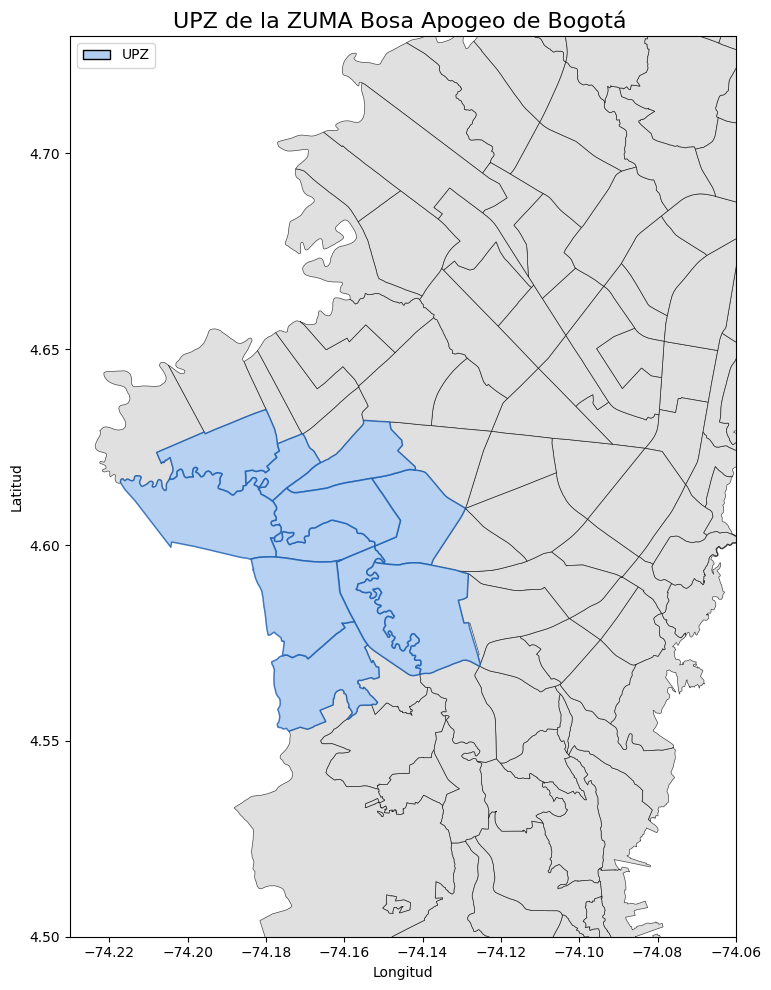

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Leer ---
# shapefiles o geodatas con la georeferenciación de la EIS 
upz = gpd.read_file("C:/Users/Usuario/OneDrive - Universidad de los andes/Archivos de EpiAndes - 3.1 HIA ZUMA/2_HEAT/taprobacionnofupz/TAprobacionNOfUPZ/TAprobacionNOfUPZ_2023.shp")
    
eis = gpd.read_file("C:/Users/Usuario/OneDrive - Universidad de los andes/Archivos de EpiAndes - 3.1 HIA ZUMA/2_HEAT/SC_ZUMA_POTOSI (1).gpkg")


#malla_vial = gpd.read_file("C:/Users/Usuario/OneDrive - Universidad de los andes/Archivos de EpiAndes - 3.1 HIA ZUMA/2_HEAT/CODIGO-METRO/redinfraestructuravialarterial.shp/RedInfraestructuraVialArterial.shp")



# ---  todo a Longitud/Latitud ---
CRS_VIS = "EPSG:4326"
upz = upz.to_crs(CRS_VIS)
eis = eis.to_crs(CRS_VIS)

# --- Filtrar UPZ  ---
upz["COD_UPZ"] = upz["COD_UPZ"].astype(str)
UPZ_eis= [str(x) for x in UPZ_eis]

upz_eis_gdf = upz[upz["COD_UPZ"].isin(UPZ_eis)]
upz_other = upz[~upz["COD_UPZ"].isin(UPZ_eis)]


# --- Plot ---

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

if not upz_other.empty:
    upz_other.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5, alpha=0.7)

if not upz_eis_gdf.empty:
    upz_eis_gdf.plot(ax=ax, color="#A4C6EED4", edgecolor="#1B5EB1D4", linewidth=1.1, alpha=0.8)




# --- Ejes y límites en lon/lat, AJUSTAR SEGÚN SEA NECESARIO  ---
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_xlim(-74.23, -74.06)
ax.set_ylim(4.5, 4.73)
ax.legend()

# --- Evitar deformación  ---
ax.set_aspect("equal", adjustable="box")

ax.set_title("UPZ de la EIS de Bogotá ", fontsize=16)


# --- Leyenda  ---

legend_elements = [
    mpatches.Patch(facecolor="#A4C6EED4", edgecolor="black", label="UPZ")
    
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True
)


plt.tight_layout()
plt.show()

In [ ]:
# Filtrar filas donde utam_ori o utam_des estén en la lista utam_EIS
filtro = (modulo_viajes_df['utam_ori'].isin(utam_EIS)) & (modulo_viajes_df['utam_des'].isin(utam_EIS))

# Aplicar el filtro
df_eis = modulo_viajes_df[filtro]

tiempo_y_personas(df_filtrao_geo=df_eis)

Caminando como modo principal
Personas: 42760.6
Tiempo promedio por persona: 35.74 min/persona

Bicicleta convencional
Personas: 22790.4
Tiempo promedio por persona: 26.74 min/persona

Caminando hacia el modo principal (acceso y egreso)
Personas: 42566.3
Tiempo promedio por persona: 13.91 min/persona

Caminata total
Personas que caminan en total: 86031.8
Tiempo promedio caminando por persona: 25.16 min/persona



C:\Users\Usuario\AppData\Local\Temp\ipykernel_31576\2060752557.py:112: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,modo_principal_agrupado,personas,min/persona
1,A PIE > 15 MIN,30432.2,46.704257
9,TRANSPORTE PÚBLICO,21790.6,19.177127
3,BICICLETA,16123.0,4.365608
0,A PIE <15 MIN,12328.4,9.181767
6,MOTO,8883.4,2.006022
2,AUTO,5117.4,13.011861
5,INFORMAL,3276.5,11.714879
4,ESPECIAL OCUPADO,818.0,15.000000
8,TAXI OCUPADO,668.7,8.598475
7,OTRO,248.2,4.000000
